In [7]:
import pandas as pd
import numpy as np
df=pd.read_csv("german.data-numeric",
sep=r"\s+",header=None)
print("Dataset Shape:",df.shape)
df.head()

Dataset Shape: (1000, 25)


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [8]:
df.isnull().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       1000 non-null   int64
 1   1       1000 non-null   int64
 2   2       1000 non-null   int64
 3   3       1000 non-null   int64
 4   4       1000 non-null   int64
 5   5       1000 non-null   int64
 6   6       1000 non-null   int64
 7   7       1000 non-null   int64
 8   8       1000 non-null   int64
 9   9       1000 non-null   int64
 10  10      1000 non-null   int64
 11  11      1000 non-null   int64
 12  12      1000 non-null   int64
 13  13      1000 non-null   int64
 14  14      1000 non-null   int64
 15  15      1000 non-null   int64
 16  16      1000 non-null   int64
 17  17      1000 non-null   int64
 18  18      1000 non-null   int64
 19  19      1000 non-null   int64
 20  20      1000 non-null   int64
 21  21      1000 non-null   int64
 22  22      1000 non-null   int64
 23  23      1000 n

In [10]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
print("Features shape:",x.shape)
print("Target shape:",y.shape)

Features shape: (1000, 24)
Target shape: (1000,)


In [11]:
y=y.map({1:0,2:1})
print(y.value_counts())

0    700
1    300
Name: 24, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (800, 24)
Testing data: (200, 24)


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print("Scaled training data shape:", x_train_scaled.shape)
print("Scaled testing data shape:", x_test_scaled.shape)

Scaled training data shape: (800, 24)
Scaled testing data shape: (200, 24)


In [19]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(x_train_scaled, y_train)
y_pred = logistic_model.predict(x_test_scaled)
print(y_pred[:10])

[0 0 0 1 0 0 0 0 1 0]


In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
y_prob = logistic_model.predict_proba(x_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC-AUC:", roc_auc)

Precision: 0.6590909090909091
Recall: 0.48333333333333334
F1-Score: 0.5576923076923077
ROC-AUC: 0.82


In [21]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(x_train, y_train)
y_pred_dt = decision_tree.predict(x_test)

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
y_prob_dt = decision_tree.predict_proba(x_test)[:, 1]
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
print("Decision Tree Results")
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1-Score:", f1_dt)
print("ROC-AUC:", roc_auc_dt)

Decision Tree Results
Precision: 0.53125
Recall: 0.5666666666666667
F1-Score: 0.5483870967741935
ROC-AUC: 0.6761904761904762


In [23]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
random_forest.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [25]:
y_pred_rf = random_forest.predict(x_test)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
y_prob_rf = random_forest.predict_proba(x_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Random Forest Results")
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-Score:", f1_rf)
print("ROC-AUC:", roc_auc_rf)

Random Forest Results
Precision: 0.6829268292682927
Recall: 0.4666666666666667
F1-Score: 0.5544554455445545
ROC-AUC: 0.7891071428571428


In [26]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Precision": [
        precision,
        precision_dt,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_dt,
        recall_rf
    ],
    "F1-Score": [
        f1,
        f1_dt,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_dt,
        roc_auc_rf
    ]
})
results

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.659091,0.483333,0.557692,0.820000
1,Decision Tree,0.531250,0.566667,0.548387,0.676190
2,Random Forest,0.682927,0.466667,0.554455,0.789107


In [32]:
results.round(4)

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6591,0.4833,0.5577,0.8200
1,Decision Tree,0.5312,0.5667,0.5484,0.6762
2,Random Forest,0.6829,0.4667,0.5545,0.7891


In [33]:
results.round(4).to_csv("credit_scoring_model_results.csv", index=False)

Matplotlib is building the font cache; this may take a moment.


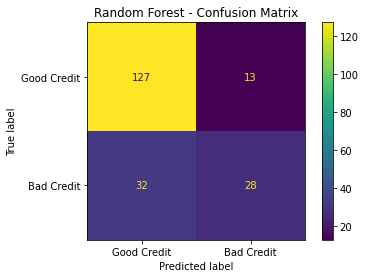

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Good Credit", "Bad Credit"]
)
disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

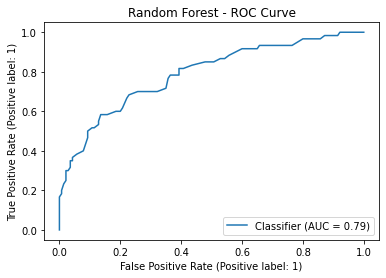

In [35]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("Random Forest - ROC Curve")
plt.show()

In [36]:
plt.savefig("random_forest_roc_curve.png", dpi=300, bbox_inches="tight")

<Figure size 432x288 with 0 Axes>

In [38]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [37]:
# Feature Engineering
x_fe = x.copy()
# Credit Amount / Duration
x_fe["credit_amount_per_month"] = x_fe.iloc[:, 3] / x_fe.iloc[:, 1]
print(x_fe.head())

   0   1  2   3  4  5  6  7  8   9  ...  15  16  17  18  19  20  21  22  23  \
0  1   6  4  12  5  5  3  4  1  67  ...   0   0   1   0   0   1   0   0   1   
1  2  48  2  60  1  3  2  2  1  22  ...   0   0   1   0   0   1   0   0   1   
2  4  12  4  21  1  4  3  3  1  49  ...   0   0   1   0   0   1   0   1   0   
3  1  42  2  79  1  4  3  4  2  45  ...   0   0   0   0   0   0   0   0   1   
4  1  24  3  49  1  3  3  4  4  53  ...   1   0   1   0   0   0   0   0   1   

   credit_amount_per_month  
0                 2.000000  
1                 1.250000  
2                 1.750000  
3                 1.880952  
4                 2.041667  

[5 rows x 25 columns]


In [39]:
x = x_fe
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (800, 25)
Testing data: (200, 25)


In [40]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print(x_train_scaled.shape)
print(x_test_scaled.shape)

(800, 25)
(200, 25)


/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(


In [41]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(x_train_scaled, y_train)
y_pred = logistic_model.predict(x_test_scaled)

In [42]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
y_prob = logistic_model.predict_proba(x_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("Logistic Regression Results")
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC-AUC:", roc_auc)

Logistic Regression Results
Precision: 0.6511627906976745
Recall: 0.4666666666666667
F1-Score: 0.5436893203883496
ROC-AUC: 0.8041666666666666


In [43]:
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(x_train, y_train)
y_pred_dt = decision_tree.predict(x_test)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
y_prob_dt = decision_tree.predict_proba(x_test)[:, 1]
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
print("Decision Tree Results")
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1-Score:", f1_dt)
print("ROC-AUC:", roc_auc_dt)

Decision Tree Results
Precision: 0.5263157894736842
Recall: 0.5
F1-Score: 0.5128205128205129
ROC-AUC: 0.6535714285714287


/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(


In [44]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
random_forest.fit(x_train, y_train)
y_pred_rf = random_forest.predict(x_test)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
y_prob_rf = random_forest.predict_proba(x_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Random Forest Results")
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-Score:", f1_rf)
print("ROC-AUC:", roc_auc_rf)

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(


Random Forest Results
Precision: 0.7368421052631579
Recall: 0.4666666666666667
F1-Score: 0.5714285714285714
ROC-AUC: 0.8006547619047618


/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(


In [45]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Precision": [
        precision,
        precision_dt,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_dt,
        recall_rf
    ],
    "F1-Score": [
        f1,
        f1_dt,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_dt,
        roc_auc_rf
    ]
})
final_results.round(4)

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6512,0.4667,0.5437,0.8042
1,Decision Tree,0.5263,0.5000,0.5128,0.6536
2,Random Forest,0.7368,0.4667,0.5714,0.8007


In [46]:
final_results.round(4).to_csv(
    "final_credit_scoring_results.csv",
    index=False
)

In [47]:
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": random_forest.feature_importances_
}).sort_values(by="Importance", ascending=False)
feature_importance.head(10)

,Feature,Importance
24,credit_amount_per_month,0.116340
3,3,0.115960
0,0,0.100887
9,9,0.098699
1,1,0.088154
2,2,0.060621
5,5,0.051860
8,8,0.048828
4,4,0.047418
6,6,0.035720


In [48]:
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": random_forest.feature_importances_
}).sort_values(by="Importance", ascending=False)
feature_importance.head(10)

,Feature,Importance
24,credit_amount_per_month,0.116340
3,3,0.115960
0,0,0.100887
9,9,0.098699
1,1,0.088154
2,2,0.060621
5,5,0.051860
8,8,0.048828
4,4,0.047418
6,6,0.035720


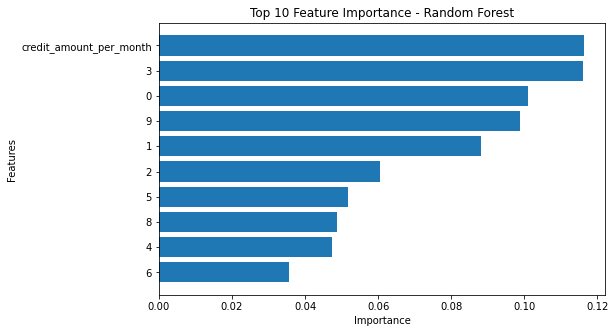

In [49]:
import matplotlib.pyplot as plt
top_features = feature_importance.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"].astype(str), top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

In [50]:
plt.savefig("top_10_feature_importance.png", dpi=300, bbox_inches="tight")

<Figure size 432x288 with 0 Axes>

In [51]:
final_results.round(4).to_csv("final_credit_scoring_results.csv", index=False)

<Figure size 432x360 with 0 Axes>

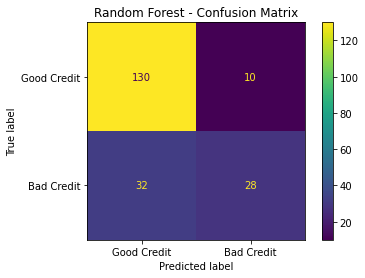

In [52]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Good Credit", "Bad Credit"]
)
disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.savefig("random_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 432x360 with 0 Axes>

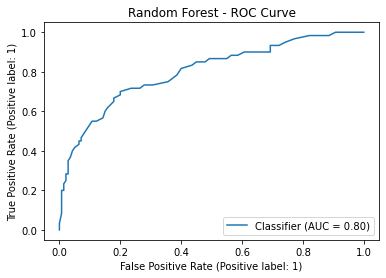

In [53]:
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("Random Forest - ROC Curve")
plt.savefig("random_forest_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()